## This is a code that splits curves, calculates the contribution of peaks, calculates segment lengths, and outputs all the data in a table.

### How to use it:

1) Run the code first

2) Then the database is automatically loaded (you don't need to load anything yourself)

3) Then a button will appear to load the curve. This means that you need to attach an xls or xslx file (tables) with only two columns (temperature and intensity).

4) Enter the requested information about the sample (name, pressure,...)

Done.

Training data not found. Downloading from Google Drive...
=== DOWNLOADING TRAINING DATA ===
File downloaded: training_examples.zip (995.4 KB)
Archive extracted successfully!

Contents of folder training_examples:
  ✓ sample_10.xlsx
  ✓ sample_07.xlsx
  ✓ sample_01.xlsx
  ✓ sample_03.xlsx
  ✓ sample_06.xlsx
  ✓ sample_02.xlsx
  ✓ sample_09.xlsx
  ✓ sample_05.xlsx
  ✓ sample_08.xlsx
  ✓ sample_04.xlsx
Total Excel files: 10
=== TRAINING MODEL ON EXAMPLES ===

Found 10 example files
Processing 1/10: sample_01.xlsx
  Extracted 6 peaks
Processing 2/10: sample_02.xlsx
  Extracted 6 peaks
Processing 3/10: sample_03.xlsx
  Extracted 6 peaks
Processing 4/10: sample_04.xlsx
  Extracted 7 peaks
Processing 5/10: sample_05.xlsx
  Extracted 7 peaks
Processing 6/10: sample_06.xlsx
  Extracted 7 peaks
Processing 7/10: sample_07.xlsx
  Extracted 7 peaks
Processing 8/10: sample_08.xlsx
  Extracted 6 peaks
Processing 9/10: sample_09.xlsx
  Extracted 6 peaks
Processing 10/10: sample_10.xlsx
  Extracted 6 p

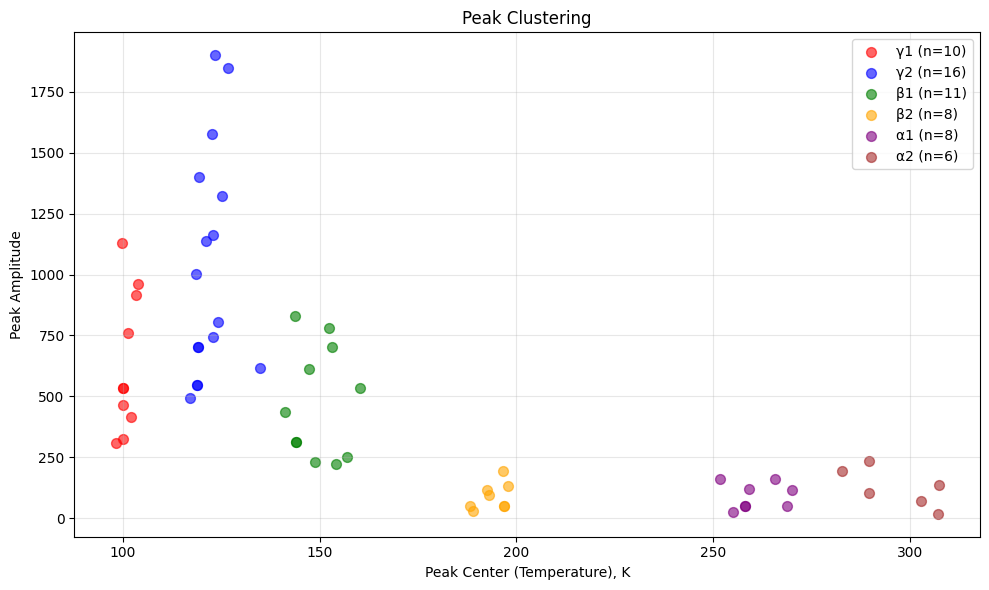


=== NEW CURVE DECOMPOSITION ===

Upload file with curve for decomposition (XLSX or XLS):


Saving fourth try.xlsx to fourth try.xlsx

SAMPLE INFORMATION INPUT
Please enter the following information about the sample:
1) Sample name: fourth try
2) Compaction pressure (MPa) [e.g., 50, 100, or 'N/A']: 100
3) Sintering pressure (MPa) [e.g., 50, 100, or '-' if not sintered]: 100
4) Sintering temperature (°C) [e.g., 130, 135, or '-' if not sintered]: 130

----------------------------------------
Sample information recorded:
  Sample_Name: fourth try
  Compaction_Pressure_MPa: 100
  Sintering_Pressure_MPa: 100
  Sintering_Temperature_C: 130
----------------------------------------
File fourth try.xlsx successfully uploaded

Cleaning data from non-numeric entries...
  Cleaned data: 1769 valid numeric points
  Removed 0 non-numeric entries

Temperature range: 79.4 - 339.3 K
Maximum intensity: 1.62e+03
Signal start: 79.4 K
Signal end: 334.2 K

Searching for baseline points...
  Found start point: (79.6K, 1.73e+02) [index 9]
  Found end point: (333.1K, 2.90e+01) [index 1719]

BASELINE:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_3535/3590538225.py:876: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


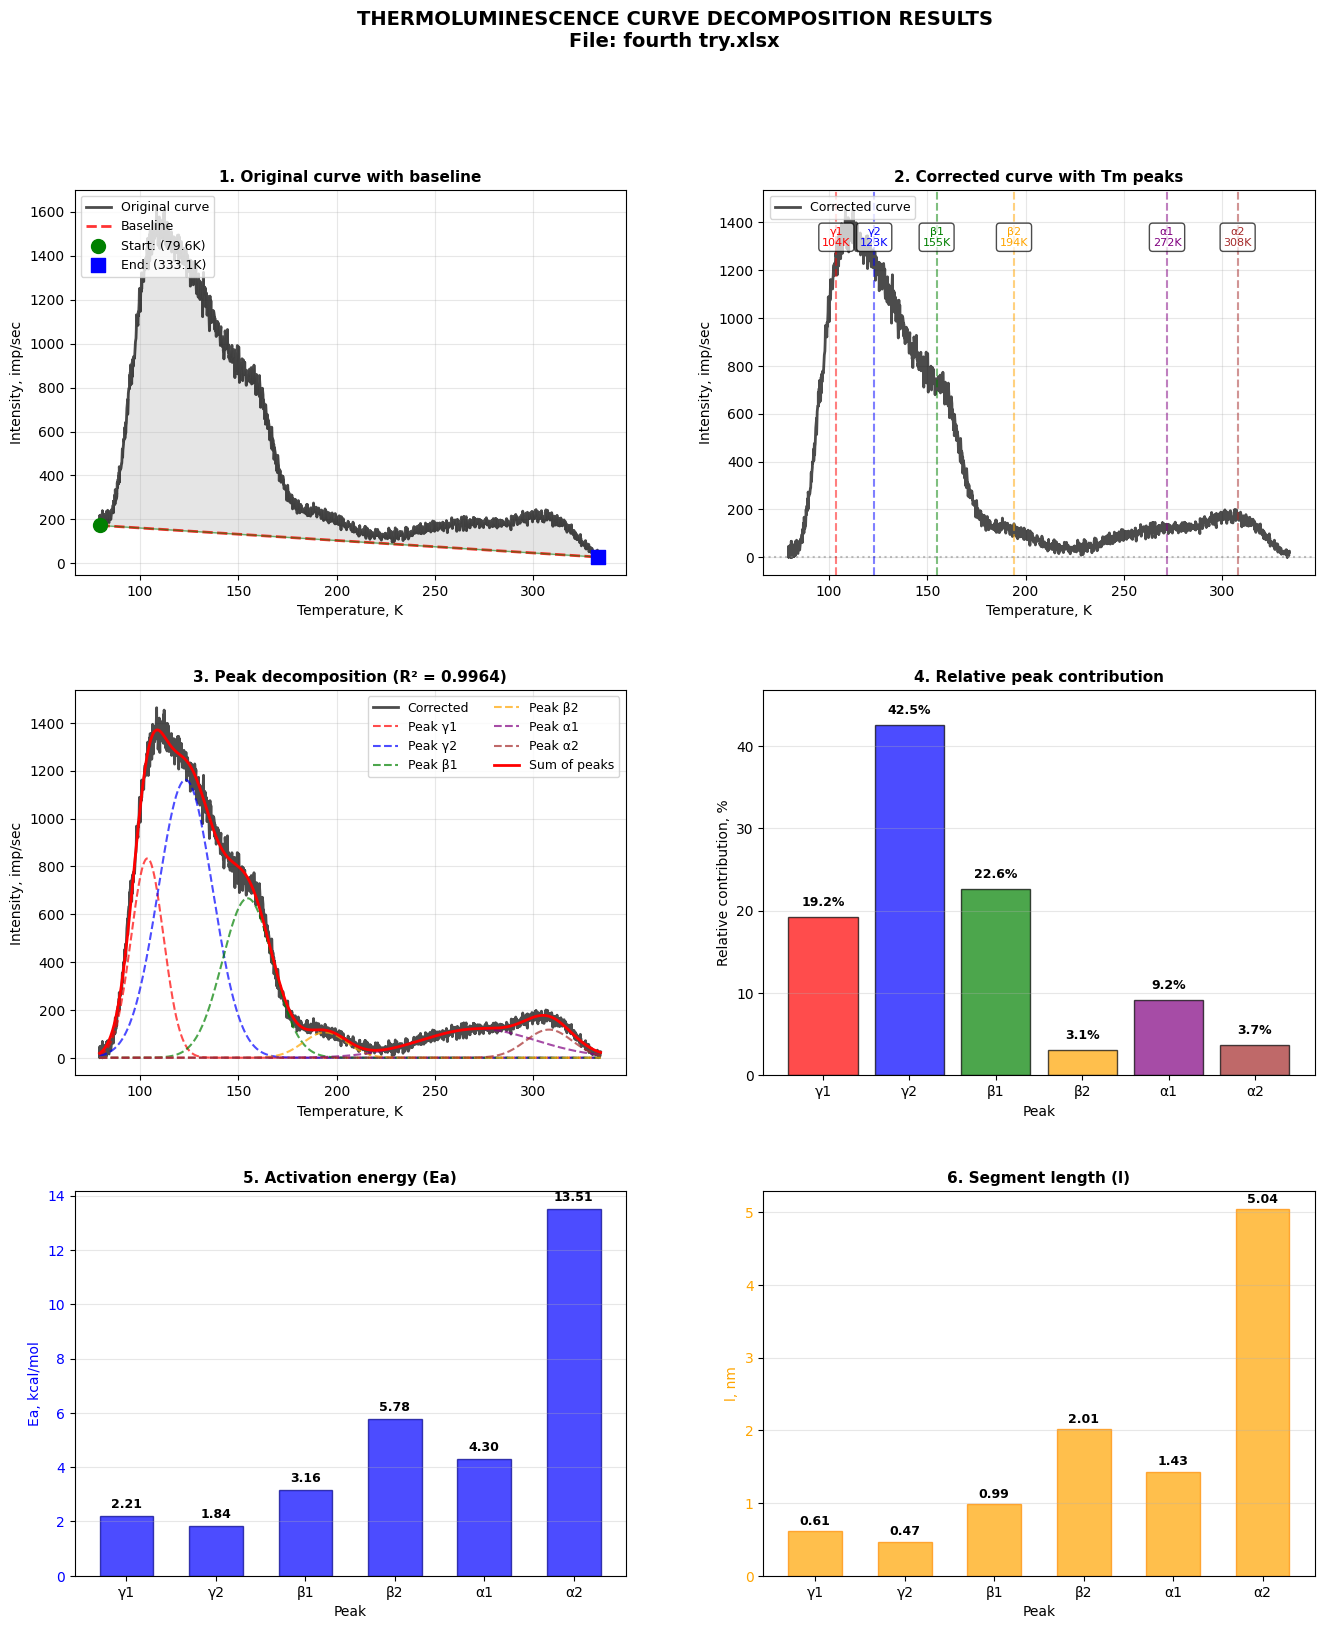


SAMPLE INFORMATION SUMMARY
Sample_Name: fourth try
Compaction_Pressure_MPa: 100
Sintering_Pressure_MPa: 100
Sintering_Temperature_C: 130

FINAL PEAK PARAMETERS TABLE

Peak        Tm, K      T", K      ΔT, K Ea, kcal/mol            N      l, nm    Contrib.%
-------------------------------------------------------------------------------------
γ1          103.8      113.4        9.7        2.212         2.42      0.613       19.22
γ2          123.1      139.4       16.4        1.840         1.84      0.467       42.52
β1          154.8      169.8       15.0        3.164         3.90      0.986       22.64
β2          194.1      207.1       13.0        5.783         7.96      2.013        3.08
α1          272.0      306.2       34.2        4.297         5.65      1.430        9.20
α2          307.9      321.8       13.9       13.509        19.94      5.044        3.71

PHYSICAL MEANING:
Tm - peak maximum temperature [K]
T" - temperature on high-temperature side at half intensity [K]
Ea - 

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from sklearn.cluster import KMeans
import pickle
import glob
import zipfile
from google.colab import files
import re
import urllib.request
import io

# ========== CONSTANTS FOR CALCULATIONS ==========
k = 1.380649e-23  # Boltzmann constant [J/K]
Na = 6.02214076e23  # Avogadro's number
E_cog = 2.15  # cohesion energy [kcal/mol]
B = 0.65  # internal rotation barrier [kcal/mol]
monomer_length = 0.253  # monomer unit length [nm]
J_to_kcal = 4184  # J to kcal conversion

def get_sample_info():
    """Asks user for sample information"""
    print("\n" + "="*60)
    print("SAMPLE INFORMATION INPUT")
    print("="*60)
    print("Please enter the following information about the sample:")

    sample_name = input("1) Sample name: ").strip()
    if not sample_name:
        sample_name = "Unknown"

    compaction_pressure = input("2) Compaction pressure (MPa) [e.g., 50, 100, or 'N/A']: ").strip()
    if not compaction_pressure:
        compaction_pressure = "N/A"

    sintering_pressure = input("3) Sintering pressure (MPa) [e.g., 50, 100, or '-' if not sintered]: ").strip()
    if not sintering_pressure:
        sintering_pressure = "-"

    sintering_temp = input("4) Sintering temperature (°C) [e.g., 130, 135, or '-' if not sintered]: ").strip()
    if not sintering_temp:
        sintering_temp = "-"

    sample_info = {
        'Sample_Name': sample_name,
        'Compaction_Pressure_MPa': compaction_pressure,
        'Sintering_Pressure_MPa': sintering_pressure,
        'Sintering_Temperature_C': sintering_temp
    }

    print("\n" + "-"*40)
    print("Sample information recorded:")
    for key, value in sample_info.items():
        print(f"  {key}: {value}")
    print("-"*40)

    return sample_info

def download_training_data():
    """Downloads training_examples.zip from Google Drive"""

    file_id = "1ixtasLuc3SPca5Go6inr5iZn4OzPuYZv"
    url = f"https://drive.google.com/uc?export=download&id={file_id}"

    print("=== DOWNLOADING TRAINING DATA ===")
    print(f"Downloading from Google Drive...")

    try:

        with urllib.request.urlopen(url) as response:
            data = response.read()

        zip_filename = 'training_examples.zip'
        with open(zip_filename, 'wb') as f:
            f.write(data)

        print(f"File downloaded: {zip_filename} ({len(data)/1024:.1f} KB)")

        with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
            zip_ref.extractall('.')

        print("Archive extracted successfully!")
        return True

    except Exception as e:
        print(f"Error downloading from Google Drive: {e}")
        print("Trying alternative download method...")

        try:
            import gdown
            url = f"https://drive.google.com/uc?id={file_id}"
            gdown.download(url, 'training_examples.zip', quiet=False)

            with zipfile.ZipFile('training_examples.zip', 'r') as zip_ref:
                zip_ref.extractall('.')
            print("Archive extracted successfully using gdown!")
            return True
        except ImportError:
            print("gdown not installed. Please install with: !pip install gdown")
            return False
        except Exception as e:
            print(f"Alternative method also failed: {e}")
            return False

EXAMPLES_FOLDER = "training_examples"

if not os.path.exists(EXAMPLES_FOLDER):
    print("Training data not found. Downloading from Google Drive...")
    download_training_data()
else:
    print(f"Training data folder '{EXAMPLES_FOLDER}' already exists.")
    print("If you want to re-download, delete the folder and run again.")

if os.path.exists(EXAMPLES_FOLDER):
    files_list = os.listdir(EXAMPLES_FOLDER)
    print(f"\nContents of folder {EXAMPLES_FOLDER}:")
    excel_files = [f for f in files_list if f.endswith(('.xlsx', '.xls'))]
    for f in excel_files[:10]:
        print(f"  ✓ {f}")
    if len(excel_files) > 10:
        print(f"  ... and {len(excel_files) - 10} more files")
    print(f"Total Excel files: {len(excel_files)}")
else:
    print(f"Folder {EXAMPLES_FOLDER} does not exist!")
    print("Please check the download or manually upload the archive.")

def gaussian(x, amp, center, width):
    return amp * np.exp(-(x - center)**2 / (2 * width**2))

def multi_gaussian(x, *params):
    y = np.zeros_like(x)
    for i in range(0, len(params), 3):
        amp, center, width = params[i:i+3]
        y += gaussian(x, amp, center, width)
    return y

def find_minimum_points(x, y, window_size=20):
    n = len(y)
    window = min(window_size, n // 4)

    start_window = y[:window]
    start_min_idx = np.argmin(start_window)
    y_start = start_window[start_min_idx]
    x_start = x[start_min_idx]
    start_idx = start_min_idx

    end_window = y[-window:]
    end_min_idx = n - window + np.argmin(end_window)
    y_end = y[end_min_idx]
    x_end = x[end_min_idx]
    end_idx = end_min_idx

    print(f"  Found start point: ({x_start:.1f}K, {y_start:.2e}) [index {start_idx}]")
    print(f"  Found end point: ({x_end:.1f}K, {y_end:.2e}) [index {end_idx}]")

    return x_start, y_start, x_end, y_end, start_idx, end_idx

def smart_linear_baseline(x, y, window_size=20):
    x_start, y_start, x_end, y_end, start_idx, end_idx = find_minimum_points(x, y, window_size)

    if x_end != x_start:
        a = (y_end - y_start) / (x_end - x_start)
    else:
        a = 0

    b = y_start - a * x_start

    baseline = a * x + b

    y_corrected = y - baseline

    y_corrected = np.maximum(y_corrected, 0)

    return y_corrected, baseline, (x_start, y_start), (x_end, y_end)

def robust_linear_baseline(x, y, window_percent=10):
    n = len(y)
    window = max(10, int(n * window_percent / 100))

    start_section = y[:window]
    y_start = np.percentile(start_section, 10)

    start_idx = np.argmin(np.abs(y[:window] - y_start))
    x_start = x[start_idx]
    y_start = y[start_idx]

    end_section = y[-window:]
    y_end = np.percentile(end_section, 10)

    end_idx = n - window + np.argmin(np.abs(y[-window:] - y_end))
    x_end = x[end_idx]
    y_end = y[end_idx]

    print(f"  Start point (percentile): ({x_start:.1f}K, {y_start:.2e})")
    print(f"  End point (percentile): ({x_end:.1f}K, {y_end:.2e})")

    if x_end != x_start:
        a = (y_end - y_start) / (x_end - x_start)
    else:
        a = 0

    b = y_start - a * x_start
    baseline = a * x + b

    y_corrected = y - baseline
    y_corrected = np.maximum(y_corrected, 0)

    return y_corrected, baseline, (x_start, y_start), (x_end, y_end)

def correct_baseline(x, y):
    print("\nSearching for baseline points...")

    try:
        y_corrected, baseline, start_point, end_point = smart_linear_baseline(x, y, window_size=20)

        if np.min(y_corrected) < -np.max(y_corrected) * 0.05:
            print("  Many negative values, trying robust method...")
            y_corrected, baseline, start_point, end_point = robust_linear_baseline(x, y)
    except:
        print("  Using robust method...")
        y_corrected, baseline, start_point, end_point = robust_linear_baseline(x, y)

    return y_corrected, baseline, start_point, end_point

def find_curve_start_end(x, y, threshold_frac=0.03):

    if len(y) > 21:
        y_smooth = savgol_filter(y, 21, 3)
    else:
        y_smooth = y.copy()

    y_max = np.max(y_smooth)
    threshold = y_max * threshold_frac

    above_threshold = y_smooth > threshold

    if not np.any(above_threshold):
        return 0, len(x) - 1

    indices = np.where(above_threshold)[0]
    start_idx = max(0, indices[0] - 5)
    end_idx = min(len(x) - 1, indices[-1] + 5)

    return start_idx, end_idx

def clean_numeric_data(df):

    # Take first two columns
    col1 = df.iloc[:, 0]
    col2 = df.iloc[:, 1]

    numeric_col1 = pd.to_numeric(col1, errors='coerce')
    numeric_col2 = pd.to_numeric(col2, errors='coerce')

    valid_mask = ~(np.isnan(numeric_col1) | np.isnan(numeric_col2))

    x_clean = numeric_col1[valid_mask].values
    y_clean = numeric_col2[valid_mask].values

    finite_mask = np.isfinite(x_clean) & np.isfinite(y_clean)
    x_clean = x_clean[finite_mask]
    y_clean = y_clean[finite_mask]

    sort_idx = np.argsort(x_clean)
    x_clean = x_clean[sort_idx]
    y_clean = y_clean[sort_idx]

    print(f"  Cleaned data: {len(x_clean)} valid numeric points")
    print(f"  Removed {len(col1) - len(x_clean)} non-numeric entries")

    return x_clean, y_clean

def calculate_peak_parameters(x, peak_data):

    max_idx = np.argmax(peak_data)
    Tm = x[max_idx]
    max_intensity = peak_data[max_idx]

    half_max = max_intensity / 2

    high_temp_indices = np.where(x > Tm)[0]
    if len(high_temp_indices) > 0:
        for idx in high_temp_indices:
            if peak_data[idx] <= half_max:
                if idx > 0:
                    x1, x2 = x[idx-1], x[idx]
                    y1, y2 = peak_data[idx-1], peak_data[idx]
                    if y2 != y1:
                        T_half = x1 + (x2 - x1) * (half_max - y1) / (y2 - y1)
                    else:
                        T_half = x[idx]
                else:
                    T_half = x[idx]
                break
        else:
            T_half = x[high_temp_indices[-1]]
    else:
        T_half = x[-1]

    delta_T = T_half - Tm
    if delta_T > 0:
        Ea = (k * Na * Tm**2) / (delta_T * J_to_kcal)
    else:
        half_max_indices = np.where(peak_data >= half_max)[0]
        if len(half_max_indices) > 1:
            fwhm = x[half_max_indices[-1]] - x[half_max_indices[0]]
            delta_T = fwhm / 2
            Ea = (k * Na * Tm**2) / (delta_T * J_to_kcal)
        else:
            delta_T = 10
            Ea = (k * Na * Tm**2) / (delta_T * J_to_kcal)

    N = (Ea - B) / (0.3 * E_cog)
    l = N * monomer_length

    return {
        'Tm': Tm,
        'T_half': T_half,
        'delta_T': delta_T,
        'Ea': Ea,
        'N': N,
        'l': l,
        'max_intensity': max_intensity
    }

def calculate_all_peaks_parameters(x, decomposed_peaks):
    peak_params = {}

    print("\n" + "="*60)
    print("CALCULATION OF PARAMETERS FOR EACH PEAK")
    print("="*60)

    for name, peak_data in decomposed_peaks.items():
        params = calculate_peak_parameters(x, peak_data)
        peak_params[name] = params

        print(f"\nPeak {name}:")
        print(f"  Tm = {params['Tm']:.1f} K")
        print(f"  T\" = {params['T_half']:.1f} K")
        print(f"  ΔT = {params['delta_T']:.1f} K")
        print(f"  Ea = {params['Ea']:.3f} kcal/mol")
        print(f"  N = {params['N']:.2f} monomer units")
        print(f"  l = {params['l']:.3f} nm")

    return peak_params

def extract_peak_params_from_example(filepath):
    try:
        df = pd.read_excel(filepath)
    except Exception as e:
        print(f"  Error reading file {filepath}: {e}")
        return np.array([])

    if len(df.columns) < 3:
        print(f"  Insufficient columns in file")
        return np.array([])

    x = df.iloc[:, 0].values

    peak_columns = []
    for col_idx in range(2, len(df.columns)):
        col_name = df.columns[col_idx]
        if col_idx == len(df.columns) - 1 and ('sum' in str(col_name).lower() or 'total' in str(col_name).lower()):
            continue
        peak_columns.append(col_name)

    all_params = []

    for col in peak_columns:
        y_peak = df[col].values

        if len(y_peak) == 0 or np.max(y_peak) < 0.01 * np.max(df.iloc[:, 1].values):
            continue

        amp_guess = np.max(y_peak)
        if amp_guess == 0:
            continue

        center_guess = x[np.argmax(y_peak)]

        half_max = amp_guess / 2
        indices = np.where(y_peak >= half_max)[0]
        if len(indices) > 1:
            fwhm = x[indices[-1]] - x[indices[0]]
            width_guess = fwhm / 2.355
        else:
            width_guess = (x[-1] - x[0]) / 20

        try:
            popt, _ = curve_fit(gaussian, x, y_peak,
                                p0=[amp_guess, center_guess, width_guess],
                                bounds=([0, x[0], 1],
                                        [amp_guess*2, x[-1], (x[-1]-x[0])/2]),
                                maxfev=5000)
            all_params.append(popt)
        except:
            all_params.append([amp_guess, center_guess, width_guess])

    return np.array(all_params)

def train_model_from_examples(examples_folder):
    all_params_list = []
    example_files = glob.glob(os.path.join(examples_folder, "*.xlsx")) + \
                   glob.glob(os.path.join(examples_folder, "*.xls"))

    example_files.sort()

    print(f"\nFound {len(example_files)} example files")

    for i, filepath in enumerate(example_files, 1):
        filename = os.path.basename(filepath)
        print(f"Processing {i}/{len(example_files)}: {filename}")
        try:
            params = extract_peak_params_from_example(filepath)
            if len(params) > 0:
                all_params_list.extend(params)
                print(f"  Extracted {len(params)} peaks")
        except Exception as e:
            print(f"  Error: {e}")

    if len(all_params_list) == 0:
        print("Failed to extract any peaks from examples!")
        return None

    all_params = np.array(all_params_list)
    print(f"\nTotal extracted peaks: {len(all_params)}")

    if len(all_params) > 5:
        n_clusters = min(6, len(all_params))
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        labels = kmeans.fit_predict(all_params[:, 1].reshape(-1, 1))

        cluster_params = {}
        for i in range(n_clusters):
            cluster_mask = labels == i
            if np.sum(cluster_mask) > 0:
                cluster_data = all_params[cluster_mask]
                cluster_centers = cluster_data[:, 1]
                cluster_widths = cluster_data[:, 2]
                cluster_amps = cluster_data[:, 0]

                # For γ1 peak
                if i == 0 and len(cluster_amps) > 3:
                    amp_threshold = np.percentile(cluster_amps, 25)
                    valid_mask = cluster_amps >= amp_threshold
                    if np.sum(valid_mask) > 0:
                        cluster_data = cluster_data[valid_mask]
                        cluster_centers = cluster_data[:, 1]
                        cluster_widths = cluster_data[:, 2]
                        cluster_amps = cluster_data[:, 0]

                cluster_params[f'cluster_{i}'] = {
                    'centers_mean': np.mean(cluster_centers),
                    'centers_std': np.std(cluster_centers),
                    'width_mean': np.mean(cluster_widths),
                    'width_std': np.std(cluster_widths),
                    'amp_mean': np.mean(cluster_amps),
                    'amp_std': np.std(cluster_amps),
                    'count': len(cluster_centers),
                    'raw_params': cluster_data
                }

        sorted_clusters = sorted(cluster_params.items(),
                                 key=lambda x: x[1]['centers_mean'])

        peak_names = ['γ1', 'γ2', 'β1', 'β2', 'α1', 'α2'][:len(sorted_clusters)]
        model_params = {}
        for (_, params), name in zip(sorted_clusters, peak_names):
            model_params[name] = params

        with open('peak_model.pkl', 'wb') as f:
            pickle.dump(model_params, f)

        print("\n=== TRAINED MODEL ===")
        for name, params in model_params.items():
            print(f"  {name}: center={params['centers_mean']:.1f}±{params['centers_std']:.1f}K, "
                  f"width={params['width_mean']:.1f}±{params['width_std']:.1f}K")

        plt.figure(figsize=(10, 6))
        colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
        for i, (name, params) in enumerate(model_params.items()):
            cluster_data = params['raw_params']
            plt.scatter(cluster_data[:, 1], cluster_data[:, 0],
                       color=colors[i], alpha=0.6, label=f'{name} (n={params["count"]})',
                       s=50)

        plt.xlabel('Peak Center (Temperature), K')
        plt.ylabel('Peak Amplitude')
        plt.title('Peak Clustering')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        return model_params
    else:
        print("Insufficient data for training (need at least 6 peaks)")
        return None

def decompose_new_curve(x, y, model_params, n_peaks=None):
    if n_peaks is None:
        n_peaks = len(model_params)

    peak_names = list(model_params.keys())[:n_peaks]
    print(f"\nUsed peak types: {', '.join(peak_names)}")

    initial_params = []
    bounds_lower = []
    bounds_upper = []

    y_max = np.max(y)

    for i, name in enumerate(peak_names):
        params = model_params[name]

        if name == 'γ1':
            amp_min = y_max * 0.1
            amp_guess = max(amp_min, y_max * 0.2)
        else:
            amp_guess = y_max * 0.15

        center_guess = params['centers_mean']
        width_guess = params['width_mean']

        initial_params.extend([amp_guess, center_guess, width_guess])

        if name == 'γ1':
            amp_lower = y_max * 0.05
            amp_upper = y_max * 0.8
        else:
            amp_lower = 0
            amp_upper = y_max * 1.0

        bounds_lower.extend([amp_lower,
                            max(x[0], center_guess - params['centers_std']*2),
                            max(1, width_guess - params['width_std']*2)])
        bounds_upper.extend([amp_upper,
                            min(x[-1], center_guess + params['centers_std']*2),
                            width_guess + params['width_std']*2])
    try:
        popt, pcov = curve_fit(multi_gaussian, x, y,
                               p0=initial_params,
                               bounds=(bounds_lower, bounds_upper),
                               maxfev=20000)
        print("Optimization successful!")
    except Exception as e:
        print(f"Optimization failed: {e}")
        popt = np.array(initial_params)

    decomposed_peaks = {}
    print("\nPeak parameters (Gaussian):")

    for i, name in enumerate(peak_names):
        amp, center, width = popt[i*3:(i+1)*3]
        decomposed_peaks[name] = gaussian(x, amp, center, width)
        print(f"  {name}: amplitude={amp:.2e}, center={center:.1f}K, width={width:.1f}K")

    # Sum
    y_sum = multi_gaussian(x, *popt)

    # R²
    ss_res = np.sum((y - y_sum) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
    print(f"\nFit quality: R² = {r_squared:.4f}")

    return decomposed_peaks, y_sum, popt, r_squared

def save_results(x, y_raw, y_corrected, baseline, decomposed_peaks, y_sum, peak_params, start_point, end_point, sample_info, peak_contributions, output_file="decomposed_result.xlsx"):

    if peak_contributions is None:
        dx = np.mean(np.diff(x))
        total_area = np.sum(y_corrected) * dx
        peak_contributions = {}
        for name, peak_data in decomposed_peaks.items():
            area = np.sum(peak_data) * dx
            peak_contributions[name] = (area / total_area) * 100

    df_main = pd.DataFrame({
        'Temperature_K': x,
        'Raw_Curve': y_raw,
        'Baseline': baseline,
        'Corrected_Curve': y_corrected
    })

    for name, peak_data in decomposed_peaks.items():
        df_main[f'Peak_{name}'] = peak_data

    df_main['Sum_Fitted'] = y_sum

    df_sample = pd.DataFrame({
        'Parameter': list(sample_info.keys()),
        'Value': list(sample_info.values())
    })

    df_params = pd.DataFrame({
        'Peak': list(peak_params.keys()),
        'Tm_K': [p['Tm'] for p in peak_params.values()],
        'T"_K': [p['T_half'] for p in peak_params.values()],
        'ΔT_K': [p['delta_T'] for p in peak_params.values()],
        'Ea_kcal_mol': [p['Ea'] for p in peak_params.values()],
        'N_monomer_units': [p['N'] for p in peak_params.values()],
        'l_nm': [p['l'] for p in peak_params.values()],
        'Max_Intensity': [p['max_intensity'] for p in peak_params.values()],
        'Relative_Contribution_%': [peak_contributions.get(name, 0) for name in peak_params.keys()]
    })

    with pd.ExcelWriter(output_file) as writer:
        df_sample.to_excel(writer, sheet_name='Sample_Information', index=False)
        df_main.to_excel(writer, sheet_name='Curve_Data', index=False)
        df_params.to_excel(writer, sheet_name='Peak_Parameters', index=False)

        df_info = pd.DataFrame({
            'Parameter': ['Baseline_Start_Point', 'Baseline_End_Point', 'R_Squared'],
            'Value': [f"({start_point[0]:.1f}K, {start_point[1]:.2e})",
                     f"({end_point[0]:.1f}K, {end_point[1]:.2e})",
                     f"{r_squared:.4f}" if 'r_squared' in locals() else "N/A"]
        })
        df_info.to_excel(writer, sheet_name='Info', index=False)

    print(f"Results saved to {output_file}")
    print(f"  - Sheet 'Sample_Information': sample metadata")
    print(f"  - Sheet 'Curve_Data': raw data and peaks")
    print(f"  - Sheet 'Peak_Parameters': calculated peak parameters with contributions")
    print(f"  - Sheet 'Info': additional information")

    files.download(output_file)

    return df_main, df_params

def plot_results(x, y_raw, y_corrected, baseline, decomposed_peaks, y_sum, peak_params, r_squared, start_point, end_point, filename):
    fig = plt.figure(figsize=(16, 18))

    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.25)

    fig.suptitle(f'THERMOLUMINESCENCE CURVE DECOMPOSITION RESULTS\nFile: {filename}',
                 fontsize=14, fontweight='bold', y=0.98)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(x, y_raw, 'k-', linewidth=2, label='Original curve', alpha=0.7)
    ax1.plot(x, baseline, 'r--', linewidth=2, label='Baseline', alpha=0.8)
    ax1.fill_between(x, baseline, y_raw, alpha=0.2, color='gray')

    ax1.scatter(start_point[0], start_point[1], color='green', s=100, zorder=5,
               label=f'Start: ({start_point[0]:.1f}K)', marker='o')
    ax1.scatter(end_point[0], end_point[1], color='blue', s=100, zorder=5,
               label=f'End: ({end_point[0]:.1f}K)', marker='s')

    ax1.plot([start_point[0], end_point[0]], [start_point[1], end_point[1]],
            'g-', linewidth=1, alpha=0.5)

    ax1.set_xlabel('Temperature, K')
    ax1.set_ylabel('Intensity, imp/sec')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)
    ax1.set_title('1. Original curve with baseline', fontsize=11, fontweight='bold')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(x, y_corrected, 'k-', linewidth=2, label='Corrected curve', alpha=0.7)
    ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']
    for i, (name, params) in enumerate(peak_params.items()):
        ax2.axvline(x=params['Tm'], color=colors[i], linestyle='--', alpha=0.5,
                   linewidth=1.5)
        ax2.text(params['Tm'], ax2.get_ylim()[1]*0.9, f'{name}\n{params["Tm"]:.0f}K',
                ha='center', va='top', fontsize=8, color=colors[i],
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7))

    ax2.set_xlabel('Temperature, K')
    ax2.set_ylabel('Intensity, imp/sec')
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(True, alpha=0.3)
    ax2.set_title('2. Corrected curve with Tm peaks', fontsize=11, fontweight='bold')

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(x, y_corrected, 'k-', linewidth=2, label='Corrected', alpha=0.7)

    for (name, peak_data), color in zip(decomposed_peaks.items(), colors):
        ax3.plot(x, peak_data, '--', color=color, alpha=0.7, linewidth=1.5, label=f'Peak {name}')

    ax3.plot(x, y_sum, 'r-', linewidth=2, label='Sum of peaks')
    ax3.set_xlabel('Temperature, K')
    ax3.set_ylabel('Intensity, imp/sec')
    ax3.legend(loc='upper right', fontsize=9, ncol=2)  # Changed to upper right
    ax3.grid(True, alpha=0.3)
    ax3.set_title(f'3. Peak decomposition (R² = {r_squared:.4f})', fontsize=11, fontweight='bold')

    ax4 = fig.add_subplot(gs[1, 1])

    dx = np.mean(np.diff(x))
    total_area = np.sum(y_corrected) * dx
    areas = {}

    for name, peak_data in decomposed_peaks.items():
        area = np.sum(peak_data) * dx
        areas[name] = area

    names = list(areas.keys())
    values = [areas[name] for name in names]
    percentages = [(v / total_area) * 100 for v in values]

    bars = ax4.bar(names, percentages, color=colors[:len(names)], alpha=0.7, edgecolor='black', linewidth=1)

    for bar, percentage in zip(bars, percentages):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{percentage:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax4.set_xlabel('Peak')
    ax4.set_ylabel('Relative contribution, %')
    ax4.set_title('4. Relative peak contribution', fontsize=11, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')
    ax4.set_ylim([0, max(percentages) * 1.1])

    ax5 = fig.add_subplot(gs[2, 0])

    x_pos = np.arange(len(names))
    width = 0.6

    ea_values = [peak_params[n]['Ea'] for n in names]
    bars_ea = ax5.bar(x_pos, ea_values, width, color='blue', alpha=0.7, edgecolor='darkblue', linewidth=1)

    for bar, val in zip(bars_ea, ea_values):
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax5.set_xlabel('Peak')
    ax5.set_ylabel('Ea, kcal/mol', color='blue')
    ax5.set_xticks(x_pos)
    ax5.set_xticklabels(names)
    ax5.tick_params(axis='y', labelcolor='blue')
    ax5.set_title('5. Activation energy (Ea)', fontsize=11, fontweight='bold')
    ax5.grid(True, alpha=0.3, axis='y')

    ax6 = fig.add_subplot(gs[2, 1])

    l_values = [peak_params[n]['l'] for n in names]
    bars_l = ax6.bar(x_pos, l_values, width, color='orange', alpha=0.7, edgecolor='darkorange', linewidth=1)

    for bar, val in zip(bars_l, l_values):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax6.set_xlabel('Peak')
    ax6.set_ylabel('l, nm', color='orange')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(names)
    ax6.tick_params(axis='y', labelcolor='orange')
    ax6.set_title('6. Segment length (l)', fontsize=11, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    if os.path.exists(EXAMPLES_FOLDER):
        print("=== TRAINING MODEL ON EXAMPLES ===")
        model = train_model_from_examples(EXAMPLES_FOLDER)
    else:
        print(f"Folder {EXAMPLES_FOLDER} not found!")
        model = None

    if model is not None:
        print("\n" + "="*50)
        print("=== NEW CURVE DECOMPOSITION ===")

        print("\nUpload file with curve for decomposition (XLSX or XLS):")
        uploaded_curve = files.upload()

        curve_filename = list(uploaded_curve.keys())[0]
        sample_info = get_sample_info()

        try:
            df_input = pd.read_excel(curve_filename)
            print(f"File {curve_filename} successfully uploaded")

            if len(df_input.columns) >= 2:
                print("\nCleaning data from non-numeric entries...")
                x_full, y_raw_full = clean_numeric_data(df_input)

                if len(x_full) == 0:
                    print("No valid numeric data found in file!")
                else:
                    print(f"\nTemperature range: {x_full[0]:.1f} - {x_full[-1]:.1f} K")
                    print(f"Maximum intensity: {np.max(y_raw_full):.2e}")
                    start_idx, end_idx = find_curve_start_end(x_full, y_raw_full)
                    print(f"Signal start: {x_full[start_idx]:.1f} K")
                    print(f"Signal end: {x_full[end_idx]:.1f} K")
                    x = x_full[start_idx:end_idx+1]
                    y_raw = y_raw_full[start_idx:end_idx+1]
                    y_corrected, baseline, start_point, end_point = correct_baseline(x, y_raw)
                    print(f"\nBASELINE:")
                    print(f"  Start point: ({start_point[0]:.1f}K, {start_point[1]:.2e})")
                    print(f"  End point: ({end_point[0]:.1f}K, {end_point[1]:.2e})")
                    print(f"  Slope: {(end_point[1] - start_point[1]) / (end_point[0] - start_point[0]):.2e}")
                    print("\nDecomposing curve into peaks...")
                    decomposed_peaks, y_sum, params, r_squared = decompose_new_curve(x, y_corrected, model)
                    peak_params = calculate_all_peaks_parameters(x, decomposed_peaks)
                    dx = np.mean(np.diff(x))
                    total_area = np.sum(y_corrected) * dx
                    peak_contributions = {}
                    print("\n" + "="*60)
                    print("PEAK CONTRIBUTIONS (Relative area under curve)")
                    print("="*60)
                    for name, peak_data in decomposed_peaks.items():
                        area = np.sum(peak_data) * dx
                        contribution = (area / total_area) * 100
                        peak_contributions[name] = contribution
                        print(f"  {name}: {contribution:.2f}% of total area")
                    print(f"  Total area: {total_area:.2e}")
                    output_filename = f"decomposed_{os.path.splitext(curve_filename)[0]}.xlsx"
                    save_results(x, y_raw, y_corrected, baseline, decomposed_peaks, y_sum,
                               peak_params, start_point, end_point, sample_info,
                               peak_contributions, output_filename)
                    plot_results(x, y_raw, y_corrected, baseline, decomposed_peaks, y_sum,
                               peak_params, r_squared, start_point, end_point, curve_filename)

                    print("\n" + "="*60)
                    print("SAMPLE INFORMATION SUMMARY")
                    print("="*60)
                    for key, value in sample_info.items():
                        print(f"{key}: {value}")

                    print("\n" + "="*60)
                    print("FINAL PEAK PARAMETERS TABLE")
                    print("="*60)

                    print("\n{:<6} {:>10} {:>10} {:>10} {:>12} {:>12} {:>10} {:>12}".format(
                        "Peak", "Tm, K", "T\", K", "ΔT, K", "Ea, kcal/mol", "N", "l, nm", "Contrib.%"))
                    print("-" * 85)

                    for name, params in peak_params.items():
                        print("{:<6} {:>10.1f} {:>10.1f} {:>10.1f} {:>12.3f} {:>12.2f} {:>10.3f} {:>11.2f}".format(
                            name, params['Tm'], params['T_half'], params['delta_T'],
                            params['Ea'], params['N'], params['l'], peak_contributions[name]))

                    print("\n" + "="*60)
                    print("PHYSICAL MEANING:")
                    print("="*60)
                    print("Tm - peak maximum temperature [K]")
                    print("T\" - temperature on high-temperature side at half intensity [K]")
                    print("Ea - activation energy of relaxation transitions [kcal/mol]")
                    print("N - number of monomer units in kinetic unit of motion")
                    print("l - length of kinetic units of motion [nm]")

            else:
                print("File must contain at least 2 columns")

        except Exception as e:
            print(f"Error: {e}")
            import traceback
            traceback.print_exc()
    else:
        print("Model not trained.")